# ST-GCN untuk Klasifikasi Mikro-Ekspresi SMIC

## Peta proyek (baca dulu sebelum sidang)

Workspace aktif ada di `python test/`. Setiap arsitektur **diisolasi** di foldernya sendiri agar checkpoint `.pth` dan notebook tidak tercampur.

```text
python test/
├── discovery/          # EDA saja — tidak ada training
│   ├── smic_data_discovery.ipynb
│   └── mmew_data_discovery.ipynb
├── stgcn/              # model graf Face Mesh (468 node)
│   ├── stgcn_mmew_extraction.ipynb
│   ├── stgcn_mmew_pretraining.ipynb
│   ├── stgcn_smic_extraction.ipynb
│   ├── stgcn_smic_training.ipynb   # LOSO + transfer MMEW
│   ├── stgcn_mmew_pretrained.pth
│   ├── stgcn_best_model.pth
│   └── stgcn_mmew_landmarks/       # 300 file .npy MMEW
├── r3d18/              # 3D-CNN R3D-18 pada klip video
│   ├── r3d18_smic_pipeline.ipynb
│   └── r3d18_best_model.pth
├── vit/                # ViT pada gambar Optical Flow
│   ├── vit_optical_flow_pipeline.ipynb
│   └── vit_best_model.pth
├── dataset/            # data mentah + hasil ekstraksi bersama
│   ├── SMIC_all_cropped/           # frame BMP ter-crop & registrasi
│   ├── MMEW/                       # JPG mikro (sekuens) + makro (still)
│   ├── stgcn_smic_landmarks/       # .npy graf SMIC
│   └── vit_optical_flow_frames/    # JPG flow untuk ImageFolder
└── requirements.txt
```

**Alur skripsi yang benar:** discovery → ekstraksi fitur → (opsional pre-train) → LOSO SMIC. Ketiga model dievaluasi dengan protokol **LOSO** yang sama agar perbandingan adil (tanpa Subject Leakage dari split 80/20).

**Letak di peta:** evaluasi akhir ST-GCN. Membaca landmark SMIC di `../dataset/stgcn_smic_landmarks/` dan checkpoint MMEW `stgcn_mmew_pretrained.pth` di folder yang sama.

**Protokol LOSO (wajib sidang):** 16 subjek HS → 16 fold. Tiap fold, satu subjek **seluruh klipnya** jadi validasi. Prediksi epoch **terakhir** (bukan best-val) diakumulasi 164 sampel, baru dihitung Accuracy / Macro F1 / UAR global.

**Subject Leakage** = klip orang yang sama ada di train dan test. Split 80/20 random melakukan itu pada SMIC karena `s3` punya 39 klip.

Notebook ini melatih **Spatial-Temporal Graph Convolutional Network (ST-GCN)** pada data graf wajah hasil `stgcn_smic_extraction.ipynb`.

Berbeda dengan CNN/ViT yang bekerja pada piksel, ST-GCN bekerja pada **graf**: 468 titik Face Mesh menjadi **node**, dan hubungan antar titik menjadi **edge**.

Pipeline:

1. Bangun **Adjacency Matrix** `A` (468×468) dari `FACEMESH_TESSELATION`
2. Normalisasi `A` agar propagasi fitur antar node stabil
3. `SMICGraphDataset` memuat file `.npy` dan mengubahnya ke format `(C, T, V)`
4. Arsitektur ST-GCN: blok **Spatial (GraphConv)** + **Temporal (TemporalConv)**
5. Training 20 epoch dengan metrik Accuracy, Macro F1, dan UAR

## Notasi dimensi

| Simbol | Arti | Nilai |
|--------|------|-------|
| `N` | Batch size | 8 |
| `C` | Channels — koordinat `(x, y, z)` | 3 |
| `T` | Time — jumlah frame | 16 |
| `V` | Vertices — node Face Mesh | 468 |

File `.npy` tersimpan sebagai `(T, V, C)`, lalu di-*transpose* menjadi `(C, T, V)` yang merupakan format standar ST-GCN.

> Jalankan `stgcn_smic_extraction.ipynb` terlebih dahulu agar folder `../dataset/stgcn_smic_landmarks/` sudah terisi.


In [1]:
# =============================================================================
# 1. IMPORT, KONFIGURASI, DAN DETEKSI DEVICE
# =============================================================================
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, f1_score, recall_score
from sklearn.model_selection import LeaveOneGroupOut
from torch.utils.data import DataLoader, Dataset, Subset
from tqdm.auto import tqdm

import mediapipe as mp

# ==========================================
# KONFIGURASI EKSEKUSI (Lokal vs Server)
# ==========================================
RUN_ON_SERVER = False  # Ubah ke True jika dijalankan di server GPU berkapasitas tinggi

if RUN_ON_SERVER:
    CFG = {
        "epochs": 150,
        "batch_size": 32,
        "use_augmentation": True,
        "patience": 20,
        "num_workers": 4
    }
else:
    CFG = {
        "epochs": 2,
        "batch_size": 4,
        "use_augmentation": False,
        "patience": 2,
        "num_workers": 0
    }

print(f"Mode eksekusi : {'SERVER' if RUN_ON_SERVER else 'LOKAL'}")
print(f"CFG           : {CFG}")

# Folder berisi hasil ekstraksi landmark (.npy)
LANDMARK_ROOT = Path('../dataset/stgcn_smic_landmarks').resolve()

# Dimensi data graf
NUM_FRAMES = 16          # T — panjang temporal
NUM_NODES = 468          # V — jumlah node Face Mesh
NUM_CHANNELS = 3         # C — koordinat (x, y, z)

# Indeks node hidung pada MediaPipe Face Mesh — dipakai sebagai titik pusat
# saat Pose Normalization agar posisi absolut wajah tidak memengaruhi model.
NOSE_INDEX = 1

# Saklar Pose Normalization. Dibuat sebagai variabel agar mudah diablasi:
# jalankan sekali True dan sekali False, lalu bandingkan metrik LOSO-nya.
# Hasil ablasi: True menurunkan Macro F1 (34.98% → 25.97%) karena SMIC sudah registrasi (reg_*.bmp).
USE_POSE_NORMALIZATION = False

# Hyperparameter training — mengikuti CFG (LOKAL vs SERVER).
BATCH_SIZE = CFG["batch_size"]
RANDOM_SEED = 42         # seed sama dengan pipeline 3D-CNN / ViT agar inisialisasi sebanding
NUM_WORKERS = CFG["num_workers"]
NUM_EPOCHS_PER_FOLD = CFG["epochs"]
USE_AUGMENTATION = CFG["use_augmentation"]

# Mapping label — urutan tetap, jangan diubah setelah training
LABEL_TO_INDEX = {'Negative': 0, 'Positive': 1, 'Surprise': 2}
INDEX_TO_LABEL = {idx: name for name, idx in LABEL_TO_INDEX.items()}
num_classes = len(LABEL_TO_INDEX)

if not LANDMARK_ROOT.is_dir():
    raise FileNotFoundError(
        f'Folder landmark tidak ditemukan: {LANDMARK_ROOT}\n'
        'Jalankan stgcn_smic_extraction.ipynb terlebih dahulu.'
    )

# --- Deteksi perangkat: CUDA NVIDIA, MPS Apple Silicon, atau CPU ---
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')

print(f'Device yang digunakan: {device}')
print(f'Landmark root : {LANDMARK_ROOT}')
print(f'Dimensi data  : (C={NUM_CHANNELS}, T={NUM_FRAMES}, V={NUM_NODES})')
print(f'Jumlah kelas  : {num_classes} -> {LABEL_TO_INDEX}')


/opt/anaconda3/envs/microsense/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device yang digunakan: mps
Landmark root : /Users/stefanieagahari/Micro-Expression-Detector/python test/dataset/stgcn_smic_landmarks
Dimensi data  : (C=3, T=16, V=468)
Jumlah kelas  : 3 -> {'Negative': 0, 'Positive': 1, 'Surprise': 2}


## 2. Adjacency Matrix dari Face Mesh

`FACEMESH_TESSELATION` berisi pasangan `(source, target)` yang membentuk jaring segitiga wajah. Pasangan inilah yang menjadi **edge** graf.

### Tahap pembentukan matriks

**1. Matriks ketetanggaan mentah**

\[ A_{ij} = 1 \text{ jika node } i \text{ terhubung ke node } j \]

Matriks dibuat **simetris** (`A[i,j] = A[j,i] = 1`) karena hubungan antar titik wajah tidak memiliki arah.

**2. Tambahkan self-loop**

\[ \tilde{A} = A + I \]

Tanpa self-loop, sebuah node hanya menerima informasi dari tetangganya dan **kehilangan fiturnya sendiri**.

**3. Symmetric normalized adjacency**

\[ \hat{A} = \tilde{D}^{-1/2} \, \tilde{A} \, \tilde{D}^{-1/2} \]

dengan \( \tilde{D} \) sebagai matriks derajat diagonal, \( \tilde{D}_{ii} = \sum_j \tilde{A}_{ij} \).

Normalisasi ini penting agar node dengan banyak tetangga tidak menghasilkan nilai aktivasi yang jauh lebih besar dibanding node dengan sedikit tetangga — sehingga training tetap stabil dan tidak meledak (*exploding activation*).
**Rumus GCN:** `Â = D^{-1/2}(A+I)D^{-1/2}`. `A+I` = self-loop. `D^{-1/2}` menormalkan derajat agar node padat (mulut, mata) tidak mendominasi node jarang (pipi). Tanpa ini, GraphConv numeriknya meledak.


In [2]:
# =============================================================================
# 2. BANGUN DAN NORMALISASI ADJACENCY MATRIX (468 x 468)
# =============================================================================
def build_adjacency_matrix(num_nodes: int = NUM_NODES) -> np.ndarray:
    """Bangun adjacency matrix simetris dari FACEMESH_TESSELATION.

    Returns
    -------
    np.ndarray
        Matriks (num_nodes, num_nodes) berisi 0/1.
    """
    connections = mp.solutions.face_mesh.FACEMESH_TESSELATION

    adjacency = np.zeros((num_nodes, num_nodes), dtype=np.float32)
    for source, target in connections:
        # Lewati koneksi ke node di luar 468 (muncul jika refine_landmarks=True)
        if source >= num_nodes or target >= num_nodes:
            continue
        # Graf wajah tidak berarah, jadi kedua arah diisi 1
        adjacency[source, target] = 1.0
        adjacency[target, source] = 1.0

    return adjacency


def normalize_adjacency(adjacency: np.ndarray) -> np.ndarray:
    """Symmetric normalized adjacency: A_hat = D^(-1/2) (A + I) D^(-1/2).

    Tanpa normalisasi, node dengan banyak tetangga akan menghasilkan nilai
    aktivasi jauh lebih besar sehingga training menjadi tidak stabil.
    """
    num_nodes = adjacency.shape[0]

    # Langkah 1: tambahkan self-loop agar fitur node sendiri ikut terbawa
    adjacency_tilde = adjacency + np.eye(num_nodes, dtype=np.float32)

    # Langkah 2: hitung derajat setiap node (jumlah koneksi termasuk dirinya)
    degree = adjacency_tilde.sum(axis=1)

    # Langkah 3: D^(-1/2); node tanpa koneksi diberi 0 agar tidak membagi nol
    degree_inv_sqrt = np.power(degree, -0.5, where=degree > 0)
    degree_inv_sqrt[degree == 0] = 0.0
    degree_matrix_inv_sqrt = np.diag(degree_inv_sqrt).astype(np.float32)

    # Langkah 4: A_hat = D^(-1/2) @ A_tilde @ D^(-1/2)
    return degree_matrix_inv_sqrt @ adjacency_tilde @ degree_matrix_inv_sqrt


adjacency_raw = build_adjacency_matrix(NUM_NODES)
adjacency_normalized = normalize_adjacency(adjacency_raw)

# Pindahkan matriks graf ke device agar perkalian matriks berjalan di GPU/MPS
A = torch.from_numpy(adjacency_normalized).to(device)

print(f'Shape adjacency        : {tuple(A.shape)}')
print(f'Total edge (dua arah)  : {int(adjacency_raw.sum())}')
print(f'Total edge (unik)      : {int(adjacency_raw.sum() // 2)}')
print(f'Rata-rata tetangga/node: {adjacency_raw.sum(axis=1).mean():.2f}')
print(f'Node tanpa koneksi     : {int((adjacency_raw.sum(axis=1) == 0).sum())}')
print(f'Rentang nilai A_hat    : {A.min().item():.4f} - {A.max().item():.4f}')
print(f'Device matriks A       : {A.device}')

Shape adjacency        : (468, 468)
Total edge (dua arah)  : 2644
Total edge (unik)      : 1322
Rata-rata tetangga/node: 5.65
Node tanpa koneksi     : 0
Rentang nilai A_hat    : 0.0000 - 0.2500
Device matriks A       : mps:0


## 3. Custom Dataset + Pose Normalization

`SMICGraphDataset` memindai `../dataset/stgcn_smic_landmarks/{kelas}/*.npy`.

### A. Pose Normalization

Koordinat mentah MediaPipe bersifat **absolut** terhadap bingkai gambar. Akibatnya dua klip dengan ekspresi identik bisa terlihat sangat berbeda hanya karena posisi kepala subjek bergeser sedikit ke kiri/kanan.

Solusinya: jadikan **hidung (node index 1)** sebagai titik pusat `(0, 0, 0)` pada **setiap frame**:

\[ p'_{t,v} = p_{t,v} - p_{t,\text{hidung}} \]

Karena pengurangan dilakukan per frame, translasi global kepala ikut terhapus sehingga model fokus pada **gerakan relatif otot wajah** — yang memang inti dari mikro-ekspresi.

Teknik ini dikendalikan lewat saklar `USE_POSE_NORMALIZATION` agar mudah diablasi.

> **Catatan hasil ablasi pada dataset ini.** Frame SMIC `SMIC_all_cropped` sudah melalui proses *crop* dan **registrasi** (nama filenya `reg_*.bmp`), artinya wajah sudah disejajarkan sejak awal oleh penyedia dataset. Pengujian LOSO menunjukkan Pose Normalization justru **menurunkan** skor: Macro F1 34,98% (nonaktif) menjadi 25,97% (aktif). Dugaan penyebabnya, karena wajah sudah teregistrasi, koordinat absolut masih memuat informasi geometri yang berguna, dan pemusatan ke hidung menghapus informasi tersebut tanpa memberi manfaat penyelarasan tambahan. Teknik ini tetap disediakan karena umum dipakai pada dataset yang **belum** teregistrasi.

### B. Transpose ke format ST-GCN

File tersimpan sebagai `(T=16, V=468, C=3)`, sedangkan ST-GCN mengharapkan `(C, T, V)`:

```text
(T, V, C)  --permute(2, 0, 1)-->  (C, T, V)
(16, 468, 3)                      (3, 16, 468)
```

Setelah di-batch oleh DataLoader, tensor menjadi `(N, C, T, V)` = `(8, 3, 16, 468)`.

### C. Subject ID untuk LOSO

Nama file mengikuti pola `{subjek}_{emosi}_{nomor}.npy`, misalnya `s1_ne_01.npy`. Bagian `s1` diekstrak sebagai **subject ID** dan disimpan pada list `groups` untuk pembagian Leave-One-Subject-Out.
**Pose Normalization (dimatikan):** `landmark - hidung`. Secara teori menghapus translasi kepala. Pada SMIC, frame sudah `reg_*.bmp` (registrasi), jadi pengurangan hidung **membuang sinyal** yang masih berguna dan terbukti menurunkan Macro F1.


In [3]:
# =============================================================================
# 3. CUSTOM DATASET: POSE NORMALIZATION + TENSOR GRAF (C, T, V)
# =============================================================================
def parse_subject_id(file_name: str) -> str:
    """Ambil ID subjek dari nama file klip.

    Contoh: 's1_ne_01.npy' -> 's1'
    """
    match = re.match(r'(s\d+)', Path(file_name).stem, flags=re.IGNORECASE)
    if match is None:
        raise ValueError(f'ID subjek tidak dapat diekstrak dari nama file: {file_name}')
    return match.group(1).lower()


class SMICGraphDataset(Dataset):
    """Dataset graf SMIC: satu file .npy = satu klip mikro-ekspresi."""

    def __init__(
        self,
        root_dir: str | Path,
        label_to_index: dict = LABEL_TO_INDEX,
        nose_index: int = NOSE_INDEX,
        pose_normalization: bool = USE_POSE_NORMALIZATION,
        augment: bool = False,
    ):
        self.root_dir = Path(root_dir)
        self.label_to_index = label_to_index
        self.nose_index = nose_index
        self.pose_normalization = pose_normalization
        self.augment = augment

        # Kumpulkan seluruh pasangan (path .npy, label integer)
        self.samples = []
        for class_name, class_index in sorted(label_to_index.items()):
            class_dir = self.root_dir / class_name
            if not class_dir.is_dir():
                continue
            for npy_path in sorted(class_dir.glob('*.npy')):
                self.samples.append((npy_path, class_index))

        if not self.samples:
            raise FileNotFoundError(
                f'Tidak ada file .npy di {self.root_dir}. '
                'Jalankan stgcn_smic_extraction.ipynb terlebih dahulu.'
            )

        # ID subjek per sampel — dipakai sebagai grup pada LOSO
        self.subject_ids = [parse_subject_id(path.name) for path, _ in self.samples]

    def __len__(self) -> int:
        return len(self.samples)

    def __getitem__(self, index: int):
        npy_path, label = self.samples[index]

        # File tersimpan sebagai (T=16, V=468, C=3)
        landmarks = np.load(npy_path).astype(np.float32)
        tensor = torch.from_numpy(landmarks)

        # --- POSE NORMALIZATION ---
        if self.pose_normalization:
            # Ambil koordinat hidung pada SETIAP frame: bentuk (T, 1, C).
            # Slicing (bukan indexing) menjaga dimensi agar broadcasting benar.
            nose_coords = tensor[:, self.nose_index:self.nose_index + 1, :]

            # Kurangi seluruh 468 titik dengan koordinat hidung di frame yang sama,
            # sehingga hidung selalu berada di (0, 0, 0). Posisi absolut kepala hilang
            # dan yang tersisa hanyalah geometri gerak relatif otot wajah.
            tensor = tensor - nose_coords

        # Transpose ke format standar ST-GCN: (C, T, V) = (3, 16, 468)
        tensor = tensor.permute(2, 0, 1).contiguous()

        # Jitter koordinat kecil HANYA saat training (USE_AUGMENTATION). Val tetap deterministik.
        if self.augment:
            tensor = tensor + 0.01 * torch.randn_like(tensor)

        return tensor, label


graph_dataset = SMICGraphDataset(LANDMARK_ROOT, augment=False)
graph_dataset_train = SMICGraphDataset(LANDMARK_ROOT, augment=USE_AUGMENTATION)

# groups[i] = ID subjek pemilik sampel ke-i, dipakai LeaveOneGroupOut
groups = graph_dataset.subject_ids
labels_all = [label for _, label in graph_dataset.samples]

print(f'Total sampel graf: {len(graph_dataset)}')
print(f'Pose Normalization: {"AKTIF" if USE_POSE_NORMALIZATION else "NONAKTIF"}')
print('Distribusi kelas:')
label_counts = pd.Series(
    [INDEX_TO_LABEL[label] for label in labels_all]
).value_counts().reindex(list(LABEL_TO_INDEX.keys()))
print(label_counts)

unique_subjects = sorted(set(groups), key=lambda s: int(s[1:]))
print(f'\nJumlah subjek unik: {len(unique_subjects)} -> akan menjadi {len(unique_subjects)} fold LOSO')
print('Jumlah klip per subjek:')
print(pd.Series(groups).value_counts().reindex(unique_subjects).to_string())

# Sanity check satu sampel + verifikasi Pose Normalization
sample_tensor, sample_label = graph_dataset[0]
nose_after = sample_tensor[:, :, NOSE_INDEX]   # (C, T) — koordinat hidung setelah normalisasi
print(f'\nContoh sampel ke-0:')
print(f'  tensor shape     : {tuple(sample_tensor.shape)}  (C, T, V)')
print(f'  label            : {sample_label} ({INDEX_TO_LABEL[sample_label]})')
print(f'  subjek           : {graph_dataset.subject_ids[0]}')
print(f'  hidung setelah normalisasi (harus ~0): max |nilai| = {nose_after.abs().max().item():.6f}')
print(f'  rentang koordinat: {sample_tensor.min().item():.3f} s/d {sample_tensor.max().item():.3f}')


Total sampel graf: 164
Pose Normalization: NONAKTIF
Distribusi kelas:
Negative    70
Positive    51
Surprise    43
Name: count, dtype: int64

Jumlah subjek unik: 16 -> akan menjadi 16 fold LOSO
Jumlah klip per subjek:
s1      6
s2      6
s3     39
s4     19
s5      2
s6      4
s8     13
s9      4
s11     7
s12     9
s13    10
s14    10
s15     4
s18     7
s19     2
s20    22

Contoh sampel ke-0:
  tensor shape     : (3, 16, 468)  (C, T, V)
  label            : 0 (Negative)
  subjek           : s11
  hidung setelah normalisasi (harus ~0): max |nilai| = 0.532697
  rentang koordinat: -0.295 s/d 1.047


In [4]:
# =============================================================================
# 4. PEMBAGIAN LEAVE-ONE-SUBJECT-OUT (LOSO)
# =============================================================================
# Split acak 80/20 TIDAK dipakai lagi. Alasannya: satu subjek bisa memiliki
# beberapa klip, sehingga split acak berpotensi menempatkan klip subjek yang
# sama di train dan val sekaligus (subject leakage). Model lalu "mengenali orang",
# bukan "mengenali ekspresi", dan skornya menjadi terlalu optimistis.
#
# LOSO menutup celah itu: pada setiap fold, SELURUH klip milik satu subjek
# dikeluarkan sebagai data validasi, dan subjek tersebut tidak pernah dilihat
# model saat training.
logo = LeaveOneGroupOut()

# Daftar pembagian indeks untuk setiap fold
fold_splits = list(logo.split(X=np.arange(len(graph_dataset)), y=labels_all, groups=groups))
n_folds = len(fold_splits)

print(f'Jumlah fold LOSO : {n_folds}')
print(f'Batch size       : {BATCH_SIZE}')
print(f'Epoch per fold   : {NUM_EPOCHS_PER_FOLD}\n')

print('Ringkasan pembagian tiap fold:')
fold_summary = []
for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):
    val_subject = groups[val_idx[0]]
    val_classes = sorted({INDEX_TO_LABEL[labels_all[i]] for i in val_idx})
    fold_summary.append({
        'fold': fold_idx + 1,
        'subjek_validasi': val_subject,
        'n_train': len(train_idx),
        'n_val': len(val_idx),
        'kelas_di_validasi': ', '.join(val_classes),
    })

fold_summary_df = pd.DataFrame(fold_summary)
print(fold_summary_df.to_string(index=False))

# --- Sanity check dimensi 1 batch dari fold pertama ---
check_idx, _ = fold_splits[0]
check_loader = DataLoader(
    Subset(graph_dataset, check_idx.tolist()),
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
)
inputs, labels = next(iter(check_loader))
print('\nSanity check 1 batch (fold 1, data train):')
print(f'  inputs shape : {tuple(inputs.shape)}  (N, C, T, V)')
print(f'  labels shape : {tuple(labels.shape)}')
print(f'  label names  : {[INDEX_TO_LABEL[int(x)] for x in labels]}')

Jumlah fold LOSO : 16
Batch size       : 8
Epoch per fold   : 15

Ringkasan pembagian tiap fold:
 fold subjek_validasi  n_train  n_val            kelas_di_validasi
    1              s1      158      6 Negative, Positive, Surprise
    2             s11      157      7 Negative, Positive, Surprise
    3             s12      155      9           Positive, Surprise
    4             s13      154     10                     Positive
    5             s14      154     10 Negative, Positive, Surprise
    6             s15      160      4 Negative, Positive, Surprise
    7             s18      157      7           Negative, Surprise
    8             s19      162      2           Positive, Surprise
    9              s2      158      6           Positive, Surprise
   10             s20      142     22 Negative, Positive, Surprise
   11              s3      125     39 Negative, Positive, Surprise
   12              s4      145     19 Negative, Positive, Surprise
   13              s5      162  

## 5. Arsitektur ST-GCN

ST-GCN memisahkan pemrosesan menjadi dua arah yang saling melengkapi.

### A. `GraphConv` — dimensi spasial (antar node)

Rumus dasar Graph Convolution:

\[ f_{out} = \hat{A} \, f_{in} \, W \]

Implementasinya dua langkah:

1. **Transformasi fitur** `W` — `Conv2d` kernel `1×1` memetakan `C_in → C_out` pada setiap node
2. **Agregasi tetangga** `Â` — perkalian matriks pada dimensi `V`:

```text
einsum('nctv,vw->nctw', x, A)
```

Artinya: fitur node `w` yang baru adalah **jumlah berbobot fitur seluruh node tetangga `v`**. Inilah inti "pesan berjalan antar titik wajah" — misalnya gerakan alis ikut memengaruhi representasi titik di sekitar mata.

### B. `TemporalConv` — dimensi waktu (antar frame)

`Conv2d` dengan kernel `(K_t, 1)`:

- Tinggi kernel `K_t = 9` menyapu **9 frame berurutan**
- Lebar kernel `1` agar setiap node diproses independen (tidak mencampur node)
- `padding = ((K_t - 1) // 2, 0)` menjaga panjang `T` tetap 16

Layer inilah yang menangkap **dinamika gerakan** — perubahan posisi titik dari frame ke frame.

### C. Blok ST-GCN

```text
input → GraphConv → BatchNorm → ReLU → TemporalConv → BatchNorm → (+residual) → ReLU
```

Koneksi **residual** membantu gradien mengalir pada tumpukan blok yang dalam.
**Tiga blok:** `3→64→64→128`. Blok pertama belajar geometri lokal (alis, bibir). Blok dalam belajar pola spatio-temporal yang lebih abstrak. Dropout 0.3 menahan overfit identitas pada 164 klip.


In [5]:
# =============================================================================
# 5. DEFINISI ARSITEKTUR ST-GCN
# =============================================================================
class GraphConv(nn.Module):
    """Graph Convolution spasial: f_out = A_hat @ f_in @ W."""

    def __init__(self, in_channels: int, out_channels: int):
        super().__init__()
        # W: transformasi fitur per node. Kernel 1x1 berarti tiap node
        # diproyeksikan sendiri-sendiri tanpa mencampur node atau waktu.
        self.transform = nn.Conv2d(in_channels, out_channels, kernel_size=1)

    def forward(self, x: torch.Tensor, adjacency: torch.Tensor) -> torch.Tensor:
        # x: (N, C_in, T, V)
        x = self.transform(x)              # (N, C_out, T, V) — bagian f_in @ W

        # Agregasi tetangga: A_hat @ f
        # 'nctv,vw->nctw' artinya untuk setiap node tujuan w, jumlahkan fitur
        # seluruh node v dengan bobot A_hat[v, w]. Inilah pertukaran informasi
        # antar titik wajah yang bertetangga pada mesh.
        # (N,C,T,V) @ A(V,V) → (N,C,T,V). Setiap node menerima rata-rata terbobot tetangganya di mesh.
        x = torch.einsum('nctv,vw->nctw', x, adjacency)
        return x.contiguous()


class TemporalConv(nn.Module):
    """Konvolusi temporal: menyapu dimensi waktu T dengan kernel (K_t, 1)."""

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 9):
        super().__init__()
        # padding hanya pada dimensi T agar panjang temporal tidak menyusut.
        # Lebar kernel = 1 supaya node tidak tercampur di tahap temporal.
        padding = ((kernel_size - 1) // 2, 0)
        self.conv = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=(kernel_size, 1),
            padding=padding,
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.conv(x)                # (N, C_out, T, V)


class STGCNBlock(nn.Module):
    """Satu blok ST-GCN: Spatial (GraphConv) diikuti Temporal (TemporalConv)."""

    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        temporal_kernel: int = 9,
        dropout: float = 0.3,
    ):
        super().__init__()
        self.graph_conv = GraphConv(in_channels, out_channels)
        self.batch_norm_spatial = nn.BatchNorm2d(out_channels)

        self.temporal_conv = TemporalConv(out_channels, out_channels, temporal_kernel)
        self.batch_norm_temporal = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout)

        # Residual: jika jumlah channel berubah, samakan dulu dengan konv 1x1
        if in_channels == out_channels:
            self.residual = nn.Identity()
        else:
            self.residual = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1),
                nn.BatchNorm2d(out_channels),
            )

    def forward(self, x: torch.Tensor, adjacency: torch.Tensor) -> torch.Tensor:
        identity = self.residual(x)

        # --- Tahap spasial: tukar informasi antar node yang bertetangga ---
        out = self.graph_conv(x, adjacency)
        out = self.relu(self.batch_norm_spatial(out))

        # --- Tahap temporal: tangkap perubahan gerak antar frame ---
        out = self.temporal_conv(out)
        out = self.batch_norm_temporal(out)
        out = self.dropout(out)

        # Residual menjaga aliran gradien pada tumpukan blok
        return self.relu(out + identity)


class STGCN_Model(nn.Module):
    """ST-GCN sederhana: 3 blok spatio-temporal + global pooling + FC."""

    def __init__(
        self,
        in_channels: int = NUM_CHANNELS,
        num_classes: int = num_classes,
        num_nodes: int = NUM_NODES,
    ):
        super().__init__()
        # Normalisasi input per node: koordinat mentah punya skala berbeda
        # antar subjek, sehingga distribusinya perlu distandarkan dulu.
        self.data_batch_norm = nn.BatchNorm1d(in_channels * num_nodes)

        self.block1 = STGCNBlock(in_channels, 64)
        self.block2 = STGCNBlock(64, 64)
        self.block3 = STGCNBlock(64, 128)

        self.fc = nn.Linear(128, num_classes)

    def forward(self, x: torch.Tensor, adjacency: torch.Tensor) -> torch.Tensor:
        # x masuk sebagai (N, C, T, V)
        batch_size, channels, num_frames, num_nodes = x.shape

        # BatchNorm1d bekerja pada (N, C*V, T), jadi susun ulang sementara
        x = x.permute(0, 1, 3, 2).contiguous()            # (N, C, V, T)
        x = x.view(batch_size, channels * num_nodes, num_frames)
        x = self.data_batch_norm(x)
        x = x.view(batch_size, channels, num_nodes, num_frames)
        x = x.permute(0, 1, 3, 2).contiguous()            # kembali ke (N, C, T, V)

        # Tumpukan blok spatio-temporal
        x = self.block1(x, adjacency)                    # (N, 64, T, V)
        x = self.block2(x, adjacency)                    # (N, 64, T, V)
        x = self.block3(x, adjacency)                    # (N, 128, T, V)

        # Global Average Pooling atas dimensi waktu (T) dan node (V):
        # seluruh klip diringkas menjadi satu vektor fitur per channel.
        # Rata-rata atas waktu dan seluruh 468 node: satu vektor per klip, siap Linear 3 kelas.
        x = x.mean(dim=(2, 3))                           # (N, 128)

        return self.fc(x)                                # (N, num_classes)


# Model di bawah hanya untuk sanity check dimensi. Model yang dipakai training
# dibuat ulang dari nol pada setiap fold LOSO (lihat cell berikutnya).
probe_model = STGCN_Model().to(device)
probe_model.eval()

with torch.no_grad():
    dummy = torch.zeros(2, NUM_CHANNELS, NUM_FRAMES, NUM_NODES, device=device)
    dummy_out = probe_model(dummy, A)

total_params = sum(p.numel() for p in probe_model.parameters())
print(f'Sanity check input  : {tuple(dummy.shape)}  (N, C, T, V)')
print(f'Sanity check output : {tuple(dummy_out.shape)}  (harus (2, {num_classes}))')
print(f'Total parameter     : {total_params:,}')
print('\nArsitektur ST-GCN siap dipakai pada LOSO.')

del probe_model


Sanity check input  : (2, 3, 16, 468)  (N, C, T, V)
Sanity check output : (2, 3)  (harus (2, 3))
Total parameter     : 247,355

Arsitektur ST-GCN siap dipakai pada LOSO.


## 6. Factory Model, Loss, Optimizer, dan Scheduler

Konfigurasi mengikuti pipeline 3D-CNN dan ViT sebelumnya, kecuali learning rate yang dinaikkan ke `1e-3` karena ST-GCN dilatih **from scratch** (tidak ada bobot pre-trained).

Perbedaan penting dibanding sebelumnya: model, optimizer, dan scheduler dibungkus dalam sebuah **factory function**.

Alasannya krusial untuk LOSO — setiap fold **wajib** dimulai dari bobot acak yang baru. Jika model dipakai ulang antar fold, bobot hasil belajar subjek sebelumnya akan terbawa (*weight leakage*) dan hasil evaluasi menjadi tidak valid.
**Mengapa factory per fold?** Jika satu instance model dipakai 16 fold, bobot subjek fold-1 merembes ke fold-2 (**weight leakage**). Itu membuat LOSO tidak sah secara akademis.

**Mengapa Adam `lr=1e-3` di sini, tetapi R3D/ViT `1e-4`?** ST-GCN dilatih from-scratch (kecuali backbone MMEW). R3D/ViT fine-tune ImageNet/Kinetics yang sudah konvergen — LR besar merusak fitur pre-trained.


In [6]:
# =============================================================================
# 6. FACTORY: MODEL, LOSS, OPTIMIZER, DAN SCHEDULER YANG SELALU BARU
# =============================================================================
criterion_gcn = nn.CrossEntropyLoss()


def create_fresh_model(seed: int = RANDOM_SEED):
    """Buat model, optimizer, dan scheduler yang benar-benar baru.

    WAJIB dipanggil di setiap fold LOSO. Kalau model lama dipakai ulang,
    bobot hasil belajar subjek fold sebelumnya akan terbawa (weight leakage)
    sehingga metrik evaluasi menjadi tidak sah.
    """
    # Seed disamakan agar setiap fold berangkat dari inisialisasi acak
    # yang sebanding — perbedaan hasil murni berasal dari data, bukan keberuntungan.
    torch.manual_seed(seed)

    model = STGCN_Model().to(device)

    # LR 1e-3 karena ST-GCN dilatih dari nol, bukan fine-tuning
    # LR 1e-3 karena blok GraphConv/TemporalConv butuh langkah lebih besar daripada fine-tune CNN.
    # weight_decay=1e-4: regularisasi L2 ringan pada 164 sampel SMIC yang mudah overfit identitas.
    optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

    # Turunkan LR 50% jika metrik validasi (mode=max) stagnan selama CFG['patience'] epoch
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='max',
        factor=0.5,
        patience=CFG["patience"],
    )
    return model, optimizer, scheduler


print('Loss      : CrossEntropyLoss')
print('Optimizer : Adam (lr=1e-3, weight_decay=1e-4)')
print(f'Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience={CFG["patience"]})')
print('Factory   : create_fresh_model() -> model, optimizer, scheduler baru per fold')


Loss      : CrossEntropyLoss
Optimizer : Adam (lr=1e-3, weight_decay=1e-4)
Scheduler : ReduceLROnPlateau (mode=max, factor=0.5, patience=3)
Factory   : create_fresh_model() -> model, optimizer, scheduler baru per fold


## 7. Fungsi Training Satu Fold

Metrik yang dihitung tetap sama dengan notebook 3D-CNN dan ViT: Accuracy, Macro F1, dan UAR (macro-recall). Pemanggilan model juga tetap `model(x, A)` karena ST-GCN butuh matriks graf sebagai argumen kedua.

### Kenapa prediksi diambil dari epoch terakhir?

Pada skema 80/20 sebelumnya, checkpoint dipilih berdasarkan Val Macro F1 tertinggi. Cara itu **tidak boleh** dipakai di LOSO, karena memilih epoch terbaik berdasarkan data validasi lalu melaporkan skor pada data validasi yang sama akan menghasilkan angka yang terlalu optimistis.

Karena itu prediksi yang diakumulasi untuk metrik global diambil dari **epoch terakhir** setiap fold — data validasi murni tak tersentuh selama training.

### Kenapa metrik dihitung global, bukan rata-rata per fold?

Banyak subjek hanya memiliki satu atau dua kelas (misalnya `s13` seluruhnya Positive). Macro F1 pada fold semacam itu tidak bermakna. Solusi standarnya: kumpulkan seluruh prediksi dari semua fold lebih dulu, baru hitung metriknya satu kali pada himpunan lengkap 164 sampel.
**Mengapa prediksi epoch terakhir, bukan val terbaik?** Memilih epoch dengan Val F1 tertinggi lalu melaporkan Val F1 yang sama adalah **optimisme berlebih**. LOSO yang jujur: train 15 epoch, ambil prediksi epoch ke-15.


In [7]:
# =============================================================================
# 7. FUNGSI TRAINING & VALIDASI ST-GCN
# =============================================================================
def compute_classification_metrics(y_true, y_pred, num_classes: int):
    """Hitung accuracy, macro-F1, dan UAR (macro-recall) dari prediksi integer."""
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    if len(y_true) == 0:
        return {'accuracy': 0.0, 'macro_f1': 0.0, 'uar': 0.0}

    accuracy = float((y_true == y_pred).mean())
    labels = list(range(num_classes))
    macro_f1 = float(
        # labels=0,1,2 dipaksa selalu dihitung. zero_division=0: subjek tanpa kelas tertentu tidak crash.
        f1_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)
    )
    uar = float(
        recall_score(y_true, y_pred, labels=labels, average='macro', zero_division=0)
    )
    return {'accuracy': accuracy, 'macro_f1': macro_f1, 'uar': uar}


def run_epoch(model, loader, criterion, optimizer, adjacency, is_training: bool):
    """Jalankan satu epoch (train atau eval) dan kembalikan loss + prediksi."""
    model.train() if is_training else model.eval()

    running_loss = 0.0
    total_samples = 0
    all_true = []
    all_pred = []

    for graphs, labels in loader:
        # graphs: (N, C, T, V) — format native ST-GCN
        graphs = graphs.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        if is_training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(is_training):
            # Matriks graf ikut dikirim sebagai argumen kedua
            outputs = model(graphs, adjacency)   # (N, num_classes)
            loss = criterion(outputs, labels)
            predictions = outputs.argmax(dim=1)

            if is_training:
                loss.backward()
                optimizer.step()

        batch_size = graphs.size(0)
        running_loss += loss.item() * batch_size
        total_samples += batch_size
        all_true.extend(labels.detach().cpu().tolist())
        all_pred.extend(predictions.detach().cpu().tolist())

    return {
        'loss': running_loss / max(total_samples, 1),
        'y_true': all_true,
        'y_pred': all_pred,
    }


def train_one_fold(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    scheduler,
    adjacency,
    num_epochs: int = NUM_EPOCHS_PER_FOLD,
    progress_desc: str = '',
):
    """Latih satu fold LOSO, lalu kembalikan prediksi dari epoch TERAKHIR.

    Tidak ada pemilihan epoch terbaik berbasis data validasi, agar metrik
    global LOSO tetap jujur (tidak bias optimistis).
    """
    history = {
        'train_loss': [],
        'train_accuracy': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_macro_f1': [],
        'val_uar': [],
        'learning_rate': [],
    }

    final_val_result = None

    for _ in tqdm(range(num_epochs), desc=progress_desc, leave=False):
        train_result = run_epoch(
            model, train_loader, criterion, optimizer, adjacency, is_training=True
        )
        val_result = run_epoch(
            model, val_loader, criterion, optimizer, adjacency, is_training=False
        )

        train_metrics = compute_classification_metrics(
            train_result['y_true'], train_result['y_pred'], num_classes
        )
        val_metrics = compute_classification_metrics(
            val_result['y_true'], val_result['y_pred'], num_classes
        )

        # Scheduler mode='max' memonitor Val Macro F1
        # Monitor Macro F1 (bukan accuracy) karena kelas Negative mayoritas. mode='max' → F1 naik = bagus.
        scheduler.step(val_metrics['macro_f1'])

        history['train_loss'].append(train_result['loss'])
        history['train_accuracy'].append(train_metrics['accuracy'])
        history['val_loss'].append(val_result['loss'])
        history['val_accuracy'].append(val_metrics['accuracy'])
        history['val_macro_f1'].append(val_metrics['macro_f1'])
        history['val_uar'].append(val_metrics['uar'])
        history['learning_rate'].append(optimizer.param_groups[0]['lr'])

        final_val_result = val_result

    # Bersihkan cache MPS di akhir fold agar memori Apple Silicon tidak menumpuk
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

    return {
        'history': history,
        'y_true': final_val_result['y_true'],
        'y_pred': final_val_result['y_pred'],
        'val_loss': history['val_loss'][-1],
        'val_accuracy': history['val_accuracy'][-1],
    }


print('Fungsi training siap:')
print('  run_epoch()      -> menjalankan satu epoch train/eval')
print('  train_one_fold() -> melatih satu fold LOSO dan mengembalikan prediksi akhir')


Fungsi training siap:
  run_epoch()      -> menjalankan satu epoch train/eval
  train_one_fold() -> melatih satu fold LOSO dan mengembalikan prediksi akhir


## 8. Jalankan LOSO Cross-Validation

Setiap subjek bergiliran menjadi data validasi. Pada setiap fold:

1. Model, optimizer, dan scheduler **di-reset total** lewat `create_fresh_model()`
2. Bobot pre-trained MMEW dimuat (`stgcn_mmew_pretrained.pth`, `strict=False`) sebagai titik awal Transfer Learning
3. Dilatih selama 15 epoch pada seluruh subjek lain
4. Prediksi epoch terakhir pada subjek yang ditahan dikumpulkan

Setelah 16 fold selesai, seluruh prediksi digabung menjadi 164 sampel dan metrik dihitung sekali secara global.

> Jalankan `stgcn_mmew_pretraining.ipynb` terlebih dahulu agar `stgcn_mmew_pretrained.pth` tersedia di folder `stgcn/`.
**Transfer Learning langkah demi langkah:** (1) `create_fresh_model()` — arsitektur SMIC 3 kelas + optimizer baru; (2) muat backbone MMEW tanpa `fc.*`; (3) `strict=False` mengizinkan kunci `fc` SMIC yang acak tetap ada; (4) fine-tune 15 epoch pada subjek lain.


In [8]:
# =============================================================================
# 8. LOOP LEAVE-ONE-SUBJECT-OUT (LOSO)
# =============================================================================
CHECKPOINT_GCN = 'stgcn_best_model.pth'
PRETRAINED_MMEW = Path('stgcn_mmew_pretrained.pth')
if not PRETRAINED_MMEW.is_file():
    raise FileNotFoundError(
        f'Checkpoint MMEW tidak ditemukan: {PRETRAINED_MMEW.resolve()}\n'
        'Jalankan stgcn_mmew_pretraining.ipynb di folder stgcn/ terlebih dahulu.'
    )

# Penampung prediksi seluruh fold. Metrik akhir dihitung dari akumulasi ini,
# BUKAN dari rata-rata metrik per fold (banyak subjek hanya punya 1-2 kelas).
loso_y_true = []
loso_y_pred = []
fold_results = []
fold_histories = {}

best_fold_accuracy = float('-inf')
best_fold_state = None
best_fold_subject = None

for fold_idx, (train_idx, val_idx) in enumerate(fold_splits):
    val_subject = groups[val_idx[0]]
    print(f'\nFold {fold_idx + 1}/{n_folds} - Validasi Subjek: {val_subject}')
    print('-' * 80)

    # --- Bagi data: seluruh klip milik val_subject ditahan sebagai validasi ---
    train_loader = DataLoader(
        Subset(graph_dataset_train, train_idx.tolist()),
        batch_size=BATCH_SIZE,
        shuffle=True,
        num_workers=NUM_WORKERS,
        persistent_workers=NUM_WORKERS > 0,
    )
    val_loader = DataLoader(
        Subset(graph_dataset, val_idx.tolist()),
        batch_size=BATCH_SIZE,
        shuffle=False,
        num_workers=NUM_WORKERS,
        persistent_workers=NUM_WORKERS > 0,
    )

    # --- RESET total: model, optimizer, dan scheduler dibuat dari nol ---
    # Tanpa ini, bobot dari fold sebelumnya terbawa (weight leakage).
    model_fold, optimizer_fold, scheduler_fold = create_fresh_model()

    # Transfer Learning dari MMEW: muat bobot pre-trained sebelum fine-tuning fold ini dimulai.
    # Kepala fc MMEW (7 kelas) tidak kompatibel dengan SMIC (3 kelas), jadi kunci fc.* dilewati.
    # strict=False saja tidak cukup: PyTorch tetap error jika shape kunci yang sama tidak cocok.
    # map_location=device: checkpoint disimpan CPU/MPS; wajib dipetakan ke device fold ini.
    try:
        pretrained_state = torch.load(PRETRAINED_MMEW, map_location=device, weights_only=True)
    except TypeError:
        pretrained_state = torch.load(PRETRAINED_MMEW, map_location=device)
    # Filter fc.* : ukuran (7,128) vs (3,128). strict=False TIDAK menoleransi size mismatch kunci yang sama.
    pretrained_backbone = {
        key: value for key, value in pretrained_state.items()
        if not key.startswith('fc.')
    }
    # strict=False: kunci fc SMIC (3 kelas) tidak ada di backbone → tetap random, itu yang diinginkan.
    model_fold.load_state_dict(pretrained_backbone, strict=False)

    fold_output = train_one_fold(
        model=model_fold,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion_gcn,
        optimizer=optimizer_fold,
        scheduler=scheduler_fold,
        adjacency=A,
        num_epochs=NUM_EPOCHS_PER_FOLD,
        progress_desc=f'Fold {fold_idx + 1} ({val_subject})',
    )

    # --- Akumulasi prediksi epoch terakhir ke penampung global ---
    loso_y_true.extend(fold_output['y_true'])
    loso_y_pred.extend(fold_output['y_pred'])
    fold_histories[val_subject] = fold_output['history']

    fold_accuracy = fold_output['val_accuracy']
    fold_results.append({
        'fold': fold_idx + 1,
        'subjek': val_subject,
        'n_train': len(train_idx),
        'n_val': len(val_idx),
        'val_loss': fold_output['val_loss'],
        'val_accuracy': fold_accuracy,
        'benar': int(np.sum(np.array(fold_output['y_true']) == np.array(fold_output['y_pred']))),
    })

    # Simpan bobot fold dengan akurasi validasi tertinggi sebagai checkpoint pakai
    if fold_accuracy > best_fold_accuracy:
        best_fold_accuracy = fold_accuracy
        best_fold_subject = val_subject
        best_fold_state = {k: v.detach().cpu().clone() for k, v in model_fold.state_dict().items()}

    print(
        f'Train Loss akhir: {fold_output["history"]["train_loss"][-1]:.4f} | '
        f'Train Acc akhir: {fold_output["history"]["train_accuracy"][-1] * 100:.2f}%'
    )
    print(
        f'Val Loss  akhir: {fold_output["val_loss"]:.4f} | '
        f'Val Accuracy   : {fold_accuracy * 100:.2f}% '
        f'({fold_results[-1]["benar"]}/{len(val_idx)} benar)'
    )

torch.save(best_fold_state, CHECKPOINT_GCN)

print('\n' + '=' * 80)
print('LOSO Cross-Validation selesai.')
print(f'Total prediksi terkumpul : {len(loso_y_true)} sampel dari {n_folds} fold')
print(f'Checkpoint tersimpan     : {CHECKPOINT_GCN} (fold terbaik: {best_fold_subject})')
print('=' * 80)



Fold 1/16 - Validasi Subjek: s1
--------------------------------------------------------------------------------



Fold 1 (s1):   0%|          | 0/15 [00:00<?, ?it/s]


Fold 1 (s1):   7%|▋         | 1/15 [00:02<00:38,  2.75s/it]


Fold 1 (s1):  13%|█▎        | 2/15 [00:05<00:32,  2.48s/it]


Fold 1 (s1):  20%|██        | 3/15 [00:07<00:28,  2.35s/it]

...


Fold 16 (s9):  80%|████████  | 12/15 [00:28<00:07,  2.39s/it]


Fold 16 (s9):  87%|████████▋ | 13/15 [00:31<00:04,  2.40s/it]


Fold 16 (s9):  93%|█████████▎| 14/15 [00:33<00:02,  2.38s/it]


Fold 16 (s9): 100%|██████████| 15/15 [00:35<00:00,  2.38s/it]

Train Loss akhir: 0.9761 | Train Acc akhir: 52.50%
Val Loss  akhir: 1.6831 | Val Accuracy   : 0.00% (0/4 benar)

LOSO Cross-Validation selesai.
Total prediksi terkumpul : 164 sampel dari 16 fold
Checkpoint tersimpan     : stgcn_best_model.pth (fold terbaik: s8)


## 9. Evaluasi Global LOSO

Seluruh prediksi dari 16 fold digabung menjadi 164 sampel, lalu metrik dihitung sekali secara global:

- **Accuracy** — proporsi prediksi benar dari seluruh sampel
- **Macro F1** — rata-rata F1 tiap kelas tanpa pembobotan jumlah sampel
- **UAR** (Unweighted Average Recall) — rata-rata recall tiap kelas, metrik standar pada literatur mikro-ekspresi karena kebal terhadap ketidakseimbangan kelas
**Macro F1 vs Accuracy:** Accuracy bisa tinggi hanya dengan menebak kelas mayoritas (Negative 70/164). Macro F1 dan UAR merata-rata ketiga kelas **tanpa bobot frekuensi**, standar literatur mikro-ekspresi.


HASIL AKHIR LEAVE-ONE-SUBJECT-OUT (LOSO) CROSS-VALIDATION
Jumlah fold          : 16 subjek
Total sampel diuji   : 164
Epoch per fold       : 15
--------------------------------------------------------------------------------
Keseluruhan Accuracy : 38.41%
Keseluruhan Macro F1 : 34.20%
Keseluruhan UAR      : 35.31%

Rincian per fold:
 fold subjek  n_train  n_val  benar  val_accuracy_%
    1     s1      158      6      4           66.67
    2    s11      157      7      2           28.57
    3    s12      155      9      0            0.00
    4    s13      154     10      0            0.00
    5    s14      154     10      2           20.00
    6    s15      160      4      3           75.00
    7    s18      157      7      3           42.86
    8    s19      162      2      0            0.00
    9     s2      158      6      1           16.67
   10    s20      142     22     16           72.73
   11     s3      125     39     12           30.77
   12     s4      145     19      8       

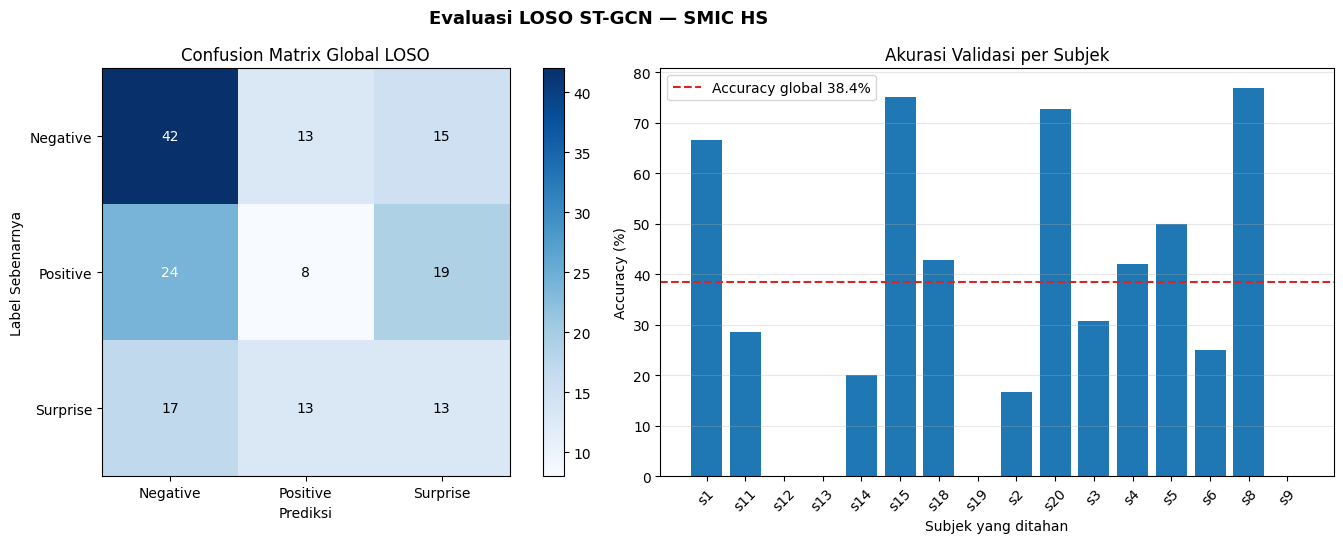


Recall per kelas (diagonal / total baris):
  Negative  : 60.00%  (42/70)
  Positive  : 15.69%  (8/51)
  Surprise  : 30.23%  (13/43)


In [9]:
# =============================================================================
# 9. METRIK GLOBAL LOSO + CONFUSION MATRIX
# =============================================================================
# Metrik dihitung SEKALI pada seluruh 164 prediksi yang terkumpul dari semua fold
global_metrics = compute_classification_metrics(loso_y_true, loso_y_pred, num_classes)

print('=' * 80)
print('HASIL AKHIR LEAVE-ONE-SUBJECT-OUT (LOSO) CROSS-VALIDATION')
print('=' * 80)
print(f'Jumlah fold          : {n_folds} subjek')
print(f'Total sampel diuji   : {len(loso_y_true)}')
print(f'Epoch per fold       : {NUM_EPOCHS_PER_FOLD}')
print('-' * 80)
print(f"Keseluruhan Accuracy : {global_metrics['accuracy'] * 100:.2f}%")
print(f"Keseluruhan Macro F1 : {global_metrics['macro_f1'] * 100:.2f}%")
print(f"Keseluruhan UAR      : {global_metrics['uar'] * 100:.2f}%")
print('=' * 80)

# --- Rincian performa tiap fold ---
fold_results_df = pd.DataFrame(fold_results)
fold_results_df['val_accuracy_%'] = (fold_results_df['val_accuracy'] * 100).round(2)
print('\nRincian per fold:')
print(
    fold_results_df[['fold', 'subjek', 'n_train', 'n_val', 'benar', 'val_accuracy_%']]
    .to_string(index=False)
)

# --- Confusion matrix global ---
class_names = list(LABEL_TO_INDEX.keys())
conf_matrix = confusion_matrix(loso_y_true, loso_y_pred, labels=list(range(num_classes)))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

# Kiri: confusion matrix seluruh prediksi LOSO
im = axes[0].imshow(conf_matrix, cmap='Blues')
axes[0].set_xticks(range(num_classes), class_names)
axes[0].set_yticks(range(num_classes), class_names)
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Label Sebenarnya')
axes[0].set_title('Confusion Matrix Global LOSO')

# Tulis angka di dalam setiap sel; warna teks menyesuaikan agar tetap terbaca
threshold = conf_matrix.max() / 2.0
for i in range(num_classes):
    for j in range(num_classes):
        axes[0].text(
            j, i, str(conf_matrix[i, j]),
            ha='center', va='center',
            color='white' if conf_matrix[i, j] > threshold else 'black',
        )
fig.colorbar(im, ax=axes[0], fraction=0.046)

# Kanan: akurasi tiap fold, garis putus-putus = akurasi global
axes[1].bar(fold_results_df['subjek'], fold_results_df['val_accuracy'] * 100, color='tab:blue')
axes[1].axhline(
    global_metrics['accuracy'] * 100,
    color='tab:red', linestyle='--',
    label=f"Accuracy global {global_metrics['accuracy'] * 100:.1f}%",
)
axes[1].set_title('Akurasi Validasi per Subjek')
axes[1].set_xlabel('Subjek yang ditahan')
axes[1].set_ylabel('Accuracy (%)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend()
axes[1].grid(alpha=0.3, axis='y')

fig.suptitle('Evaluasi LOSO ST-GCN — SMIC HS', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Recall per kelas: memperlihatkan kelas mana yang paling sulit dikenali ---
print('\nRecall per kelas (diagonal / total baris):')
for class_index, class_name in enumerate(class_names):
    row_total = conf_matrix[class_index].sum()
    recall = conf_matrix[class_index, class_index] / row_total if row_total else 0.0
    print(f'  {class_name:10s}: {recall * 100:5.2f}%  ({conf_matrix[class_index, class_index]}/{row_total})')